# EDA по ценам на топливо

**Цель.** Подтвердить, что ряды месячных розничных цен на топливо из `fuel_prices.parquet` (индикатор Росстата 31448, 2014–2025, 85 регионов × 4 марки) пригодны для прогноза **SARIMA**.

1. Линейные графики 5–7 регионов × 4 марки.
2. Тест Дики-Фуллера (ADF) на исходных рядах и первых разностях.
3. Декомпозиция на тренд / сезонность / остаток (period=12).
4. ACF / PACF — стартовые \((p,d,q)(P,D,Q,12)\).
5. Пропуски / выбросы / ступенчатые сдвиги (2014, 2022).
6. Корреляция между регионами и марками.


In [1]:
from __future__ import annotations
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

REPO = Path.cwd().resolve()
while not (REPO / 'ml' / 'data' / 'processed' / 'fuel_prices.parquet').exists():
    REPO = REPO.parent
    if REPO == REPO.parent:
        raise FileNotFoundError('fuel_prices.parquet not found upstream of cwd')
FUEL = REPO / 'ml' / 'data' / 'processed' / 'fuel_prices.parquet'
REGIONS = REPO / 'ml' / 'data' / 'seed' / 'regions.csv'
REPO, FUEL.exists(), REGIONS.exists()

(WindowsPath('C:/Users/Polina/Documents/diplom(new_version)'), True, True)

In [2]:
df = pd.read_parquet(FUEL).sort_values(['region_id', 'fuel_type', 'price_month']).reset_index(drop=True)
regions = pd.read_csv(REGIONS).set_index('id')
df = df.merge(regions[['name', 'climate_zone', 'federal_district']], left_on='region_id', right_index=True)
df['price_rub_per_l'] = df['price_rub_per_l'].astype(float)
print('rows:', len(df), 'regions:', df['region_id'].nunique(), 'fuels:', df['fuel_type'].nunique())
print('range:', df['price_month'].min().strftime('%Y-%m'), '..', df['price_month'].max().strftime('%Y-%m'))
df.head()

rows: 44474 regions: 85 fuels: 4
range: 2014-01 .. 2025-12


,region_id,fuel_type,price_rub_per_l,price_month,source,ingested_at,name,climate_zone,federal_district
0,1,ai92,29.930000,2014-01-01,rosstat_emiss,2026-04-27 21:35:51.153033+00:00,Москва,central,Центральный
1,1,ai92,30.010000,2014-02-01,rosstat_emiss,2026-04-27 21:35:51.153033+00:00,Москва,central,Центральный
2,1,ai92,30.410000,2014-03-01,rosstat_emiss,2026-04-27 21:35:51.153033+00:00,Москва,central,Центральный
3,1,ai92,30.780001,2014-04-01,rosstat_emiss,2026-04-27 21:35:51.153033+00:00,Москва,central,Центральный
4,1,ai92,31.080000,2014-05-01,rosstat_emiss,2026-04-27 21:35:51.153033+00:00,Москва,central,Центральный


## построение помесячного ряда `(region, fuel) -> Series[price]`

In [3]:
def make_series(region_id: int, fuel: str) -> pd.Series:
    sub = df[(df['region_id'] == region_id) & (df['fuel_type'] == fuel)]
    if sub.empty:
        return pd.Series(dtype=float)
    s = sub.set_index('price_month')['price_rub_per_l'].sort_index()
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq='MS')
    return s.reindex(full_idx)

FOCUS = [
    (1,  'Москва'),
    (19, 'Санкт-Петербург'),
    (33, 'Краснодарский край'),
    (52, 'Нижегородская область'),
    (60, 'Свердловская область'),
    (70, 'Новосибирская область'),
    (76, 'Республика Саха (Якутия)'),
]
[(rid, name, len(make_series(rid, 'ai95'))) for rid, name in FOCUS]

[(1, 'Москва', 144),
 (19, 'Санкт-Петербург', 144),
 (33, 'Краснодарский край', 144),
 (52, 'Нижегородская область', 144),
 (60, 'Свердловская область', 144),
 (70, 'Новосибирская область', 144),
 (76, 'Республика Саха (Якутия)', 144)]

## 1. Линейные графики 5–7 регионов × 4 марки
Видна общая инфляционная составляющая, ступенчатые сдвиги (2014, 2022) и слабая сезонность. АИ-98 в ряде регионов начинается с 2018 г.

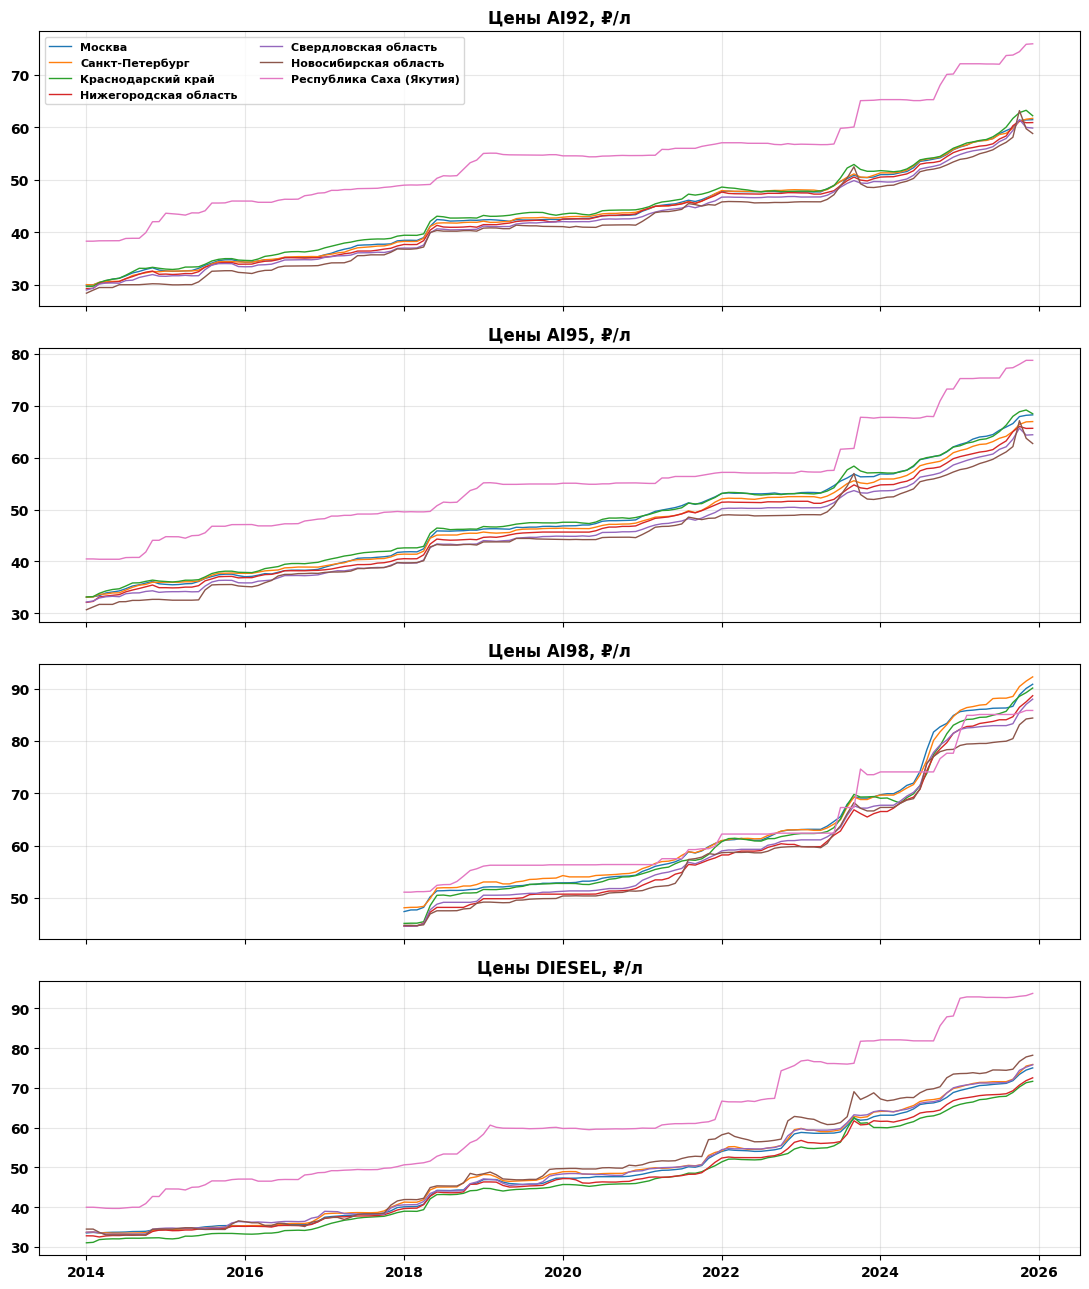

In [4]:
FUELS = ['ai92', 'ai95', 'ai98', 'diesel']
fig, axes = plt.subplots(len(FUELS), 1, figsize=(11, 13), sharex=True)
for ax, fuel in zip(axes, FUELS):
    for rid, name in FOCUS:
        s = make_series(rid, fuel)
        if s.empty:
            continue
        ax.plot(s.index, s.values, label=name, lw=1.0)
    ax.set_title(f'Цены {fuel.upper()}, ₽/л')
    ax.grid(True, alpha=.3)
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 2. Тест Дики-Фуллера (ADF)
**H₀:** ряд имеет единичный корень (нестационарен). Отвергаем при p &lt; 0.05.

Считаем для каждого ряда `(region, fuel)` ADF на исходном ряде и на первой разности и смотрим долю стационарных.

In [5]:
def adf_p(s: pd.Series) -> float:
    s = s.dropna()
    if len(s) < 24:
        return np.nan
    try:
        return adfuller(s.values, autolag='AIC')[1]
    except Exception:
        return np.nan

rows = []
for rid in df['region_id'].unique():
    for fuel in FUELS:
        s = make_series(rid, fuel).dropna()
        if len(s) < 36:
            continue
        p0 = adf_p(s)
        p1 = adf_p(s.diff().dropna())
        rows.append({'region_id': rid, 'fuel': fuel, 'adf_p_level': p0, 'adf_p_diff1': p1})
adf_df = pd.DataFrame(rows)
summary = adf_df.groupby('fuel').agg(
    n=('region_id', 'size'),
    stat_level_pct=('adf_p_level', lambda x: round(100 * (x < 0.05).mean(), 1)),
    stat_diff1_pct=('adf_p_diff1', lambda x: round(100 * (x < 0.05).mean(), 1)),
    median_p_level=('adf_p_level', 'median'),
    median_p_diff1=('adf_p_diff1', 'median'),
)
summary

,n,stat_level_pct,stat_diff1_pct,median_p_level,median_p_diff1
fuel,,,,,
ai92,85,0.0,97.6,0.996486,3.869723e-12
ai95,85,0.0,97.6,0.998138,4.698194e-12
ai98,82,0.0,90.2,0.996884,1.984711e-05
diesel,85,0.0,65.9,0.998342,1.668750e-11


**Интерпретация.** Высокая доля стационарных рядов **на первой разности** при низкой — на исходном уровне указывает на интеграцию I(1): SARIMA с **d=1** разумна как стартовая гипотеза.

## 3. Сезонная декомпозиция (period=12)
Разложение `seasonal_decompose` (additive) для одной репрезентативной пары — `Москва, AI-95`.

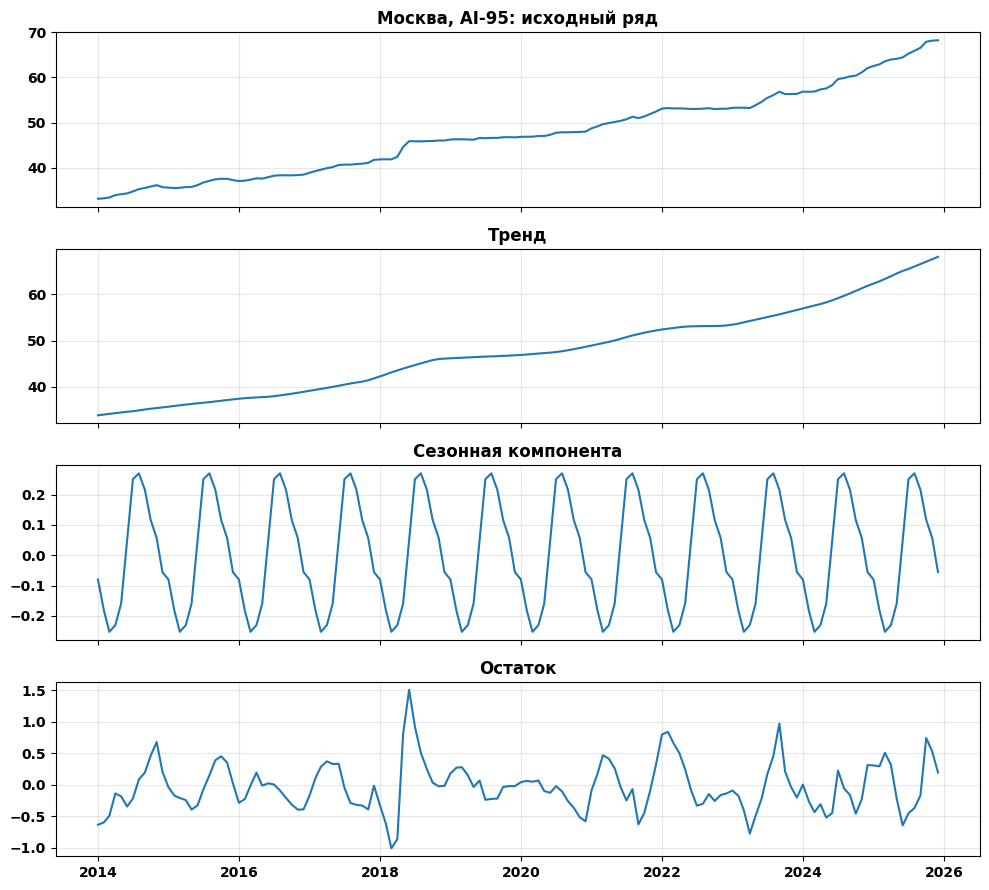

Размах сезонной компоненты: 0.52 ₽/л при средней цене 47.55 ₽/л (1.1 %).


In [6]:
s = make_series(1, 'ai95').dropna()
dec = seasonal_decompose(s, model='additive', period=12, extrapolate_trend='freq')
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
axes[0].plot(s.index, s.values); axes[0].set_title('Москва, AI-95: исходный ряд')
axes[1].plot(dec.trend.index, dec.trend.values); axes[1].set_title('Тренд')
axes[2].plot(dec.seasonal.index, dec.seasonal.values); axes[2].set_title('Сезонная компонента')
axes[3].plot(dec.resid.index, dec.resid.values); axes[3].set_title('Остаток')
for ax in axes: ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()
amp = dec.seasonal.max() - dec.seasonal.min()
print(f'Размах сезонной компоненты: {amp:.2f} ₽/л при средней цене {s.mean():.2f} ₽/л ({100*amp/s.mean():.1f} %).')

**Вывод.** Сезонная компонента небольшая (на уровне 1–3 % от средней цены): тренд доминирует. В SARIMA имеет смысл относительно слабая годовая сезонность \((P,D,Q)\).

## 4. ACF / PACF и стартовые параметры SARIMA

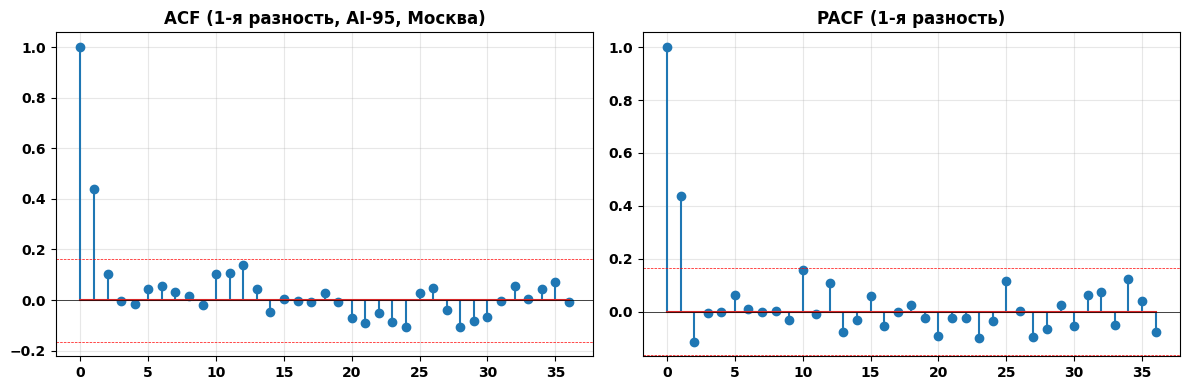

In [7]:
s = make_series(1, 'ai95').dropna()
ds = s.diff().dropna()
lags = 36
acf_v = acf(ds, nlags=lags, fft=False)
pacf_v = pacf(ds, nlags=lags, method='ywm')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(len(acf_v)), acf_v); axes[0].set_title('ACF (1-я разность, AI-95, Москва)')
axes[1].stem(range(len(pacf_v)), pacf_v); axes[1].set_title('PACF (1-я разность)')
for ax in axes:
    ax.axhline(0, color='k', lw=.5)
    ax.axhline(+1.96/np.sqrt(len(ds)), color='r', lw=.5, ls='--')
    ax.axhline(-1.96/np.sqrt(len(ds)), color='r', lw=.5, ls='--')
    ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

**Стартовые гипотезы SARIMA** (на основе p&lt;0.05 после d=1, слабой сезонности и неглубокой ACF/PACF):

| Параметр | Старт |
|---|---|
| \((p, d, q)\) | **(1, 1, 1)** |
| \((P, D, Q)_{12}\) | **(0, 1, 1)** или (1, 0, 0) |
| Период | 12 (годовой) |

Дальше — `pmdarima.auto_arima` или ручная сетка по AIC/BIC на отложенной выборке.

## 5. Пропуски, выбросы, ступенчатые сдвиги

In [8]:
missing = (
    df.assign(present=1)
      .pivot_table(index='price_month', columns='fuel_type', values='present', aggfunc='count')
      .reindex(pd.date_range(df['price_month'].min(), df['price_month'].max(), freq='MS'))
      .fillna(0).astype(int)
)
missing.tail(6)

fuel_type,ai92,ai95,ai98,diesel
2025-07-01,85,85,82,85
2025-08-01,85,85,82,85
2025-09-01,85,85,82,85
2025-10-01,85,85,82,85
2025-11-01,85,85,82,85
2025-12-01,85,85,82,85


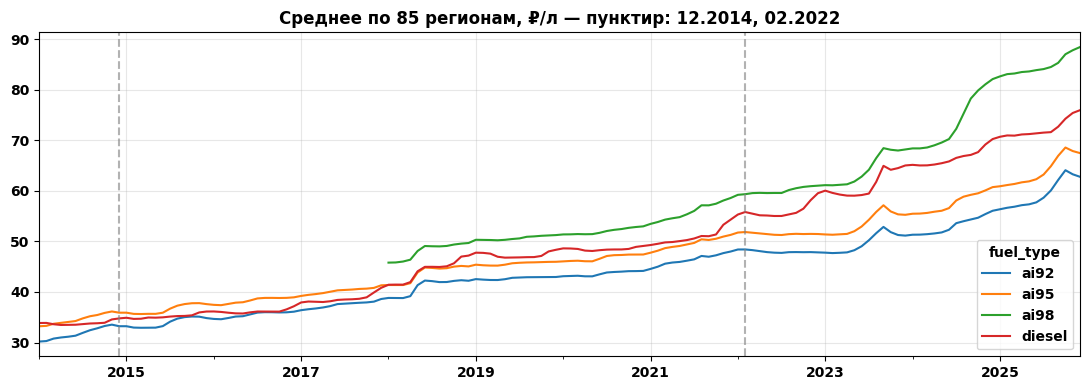

In [9]:
agg = df.groupby(['price_month', 'fuel_type'])['price_rub_per_l'].mean().unstack()
fig, ax = plt.subplots(figsize=(11, 4))
agg.plot(ax=ax)
for x in (pd.Timestamp('2014-12-01'), pd.Timestamp('2022-02-01')):
    ax.axvline(x, color='gray', ls='--', alpha=.6)
ax.set_title('Среднее по 85 регионам, ₽/л — пунктир: 12.2014, 02.2022')
ax.set_xlabel(''); ax.grid(True, alpha=.3); plt.tight_layout(); plt.show()

In [10]:
yoy = agg.pct_change(12) * 100
max_jumps = yoy.abs().max().rename('max |YoY|, %').to_frame()
max_jumps['date_of_max'] = yoy.abs().idxmax().dt.strftime('%Y-%m')
max_jumps

,"max |YoY|, %",date_of_max
fuel_type,,
ai92,17.180549,2025-10
ai95,15.205548,2025-10
ai98,21.475628,2025-02
diesel,17.793137,2018-11


**Вывод.** В рядах есть характерные ступеньки декабря 2014 и весны 2022 — это **известные структурные сдвиги**, не выбросы. На длине 144 месяца их влияние «гасится» на горизонте обучения; для SARIMA на коротких окнах имеет смысл рассматривать **разделение на до/после-сдвиг** или ввод дамми (backlog).

## 6. Корреляция по регионам и маркам

In [11]:
wide = (
    df.pivot_table(index='price_month',
                   columns=['fuel_type', 'region_id'],
                   values='price_rub_per_l')
      .sort_index()
)
ai95 = wide['ai95'].diff().dropna(how='all')
corr = ai95.corr()
stats = {
    'mean_corr': float(corr.values[np.triu_indices_from(corr, k=1)].mean()),
    'median_corr': float(np.median(corr.values[np.triu_indices_from(corr, k=1)])),
    'min_corr': float(np.min(corr.values[np.triu_indices_from(corr, k=1)])),
}
stats

{'mean_corr': 0.6008987996427955,
 'median_corr': 0.6575912594845272,
 'min_corr': -0.26400235213892337}

In [12]:
fuel_corr = (df.pivot_table(index=['price_month', 'region_id'], columns='fuel_type',
                            values='price_rub_per_l').diff().dropna()).corr()
fuel_corr

fuel_type,ai92,ai95,ai98,diesel
fuel_type,,,,
ai92,1.000000,0.939923,0.566813,0.767485
ai95,0.939923,1.000000,0.657420,0.741823
ai98,0.566813,0.657420,1.000000,0.567769
diesel,0.767485,0.741823,0.567769,1.000000


**Вывод.** Региональные ряды по AI-95 после первой разности имеют высокую среднюю корреляцию (сильный общий драйвер — макро/курс/акцизы), что подтверждает идею **многомерных моделей** или иерархических SARIMA — это backlog. Между марками топлива корреляции ещё выше (~0.9).

## Итоги

1. Покрытие: **85 регионов × 4 марки × 144 месяца** (2014–2025) — достаточно для SARIMA с годовой сезонностью.
2. **I(1)** подтверждена: ряды нестационарны на уровне, стационарны на первой разности.
3. Сезонность слабая (1–3 % от среднего); ступенчатые сдвиги 12.2014 и 02.2022 учитываем в выборе обучающего окна.
4. Стартовые SARIMA-параметры: \((p,d,q)=(1,1,1)\), \((P,D,Q)_{12}=(0,1,1)\).
5. Сильная межрегиональная корреляция.